# Predictive Maintenance: Remaining Useful Life (RUL) Prediction

## Objective
The aim of this notebook is to predict **Remaining Useful Life (RUL) in hours** using machine sensor, environmental, and maintenance-related features.  
This is a **regression problem**, where the target variable is `rul_hours`.

## Workflow
1. Import libraries  
2. Load and inspect the dataset  
3. Perform focused exploratory data analysis (EDA)  
4. Clean the data and handle missing values  
5. Prepare features for modelling  
6. Train and compare multiple regression models  
7. Evaluate the best-performing model  
8. Explore advanced experiments such as LightGBM and hyperparameter tuning

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## 1. Load the Dataset

In [3]:
# Load the dataset
data = pd.read_csv("D:\ML Assignment\data\predictive_maintenance_v3.csv")

# Preview the first few rows
data.head()

<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\prana\AppData\Local\Temp\ipykernel_9448\3936845778.py:2: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv("D:\ML Assignment\data\predictive_maintenance_v3.csv")


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


## 2. Initial Data Understanding

In [4]:
# Shape of the dataset
data.shape

(24042, 15)

In [5]:
# Column names
data.columns.tolist()

['timestamp',
 'machine_id',
 'machine_type',
 'vibration_rms',
 'temperature_motor',
 'current_phase_avg',
 'pressure_level',
 'rpm',
 'operating_mode',
 'hours_since_maintenance',
 'ambient_temp',
 'rul_hours',
 'failure_within_24h',
 'failure_type',
 'estimated_repair_cost']

In [6]:
# Basic dataset information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                24042 non-null  str    
 1   machine_id               24042 non-null  int64  
 2   machine_type             24042 non-null  str    
 3   vibration_rms            23042 non-null  float64
 4   temperature_motor        23208 non-null  float64
 5   current_phase_avg        23311 non-null  float64
 6   pressure_level           23118 non-null  float64
 7   rpm                      23509 non-null  float64
 8   operating_mode           24042 non-null  str    
 9   hours_since_maintenance  24042 non-null  float64
 10  ambient_temp             24042 non-null  float64
 11  rul_hours                24042 non-null  float64
 12  failure_within_24h       24042 non-null  int64  
 13  failure_type             24042 non-null  str    
 14  estimated_repair_cost    24042 no

In [7]:
# Summary statistics for numerical columns
data.describe()

,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost
count,24042.000000,23042.000000,23208.000000,23311.000000,23118.000000,23509.000000,24042.000000,24042.000000,24042.000000,24042.000000,24042.000000
mean,10.505033,1.623667,51.404295,8.823829,59.012233,1144.849317,172.630624,12.996398,27.812510,0.148074,608.870144
std,5.746455,1.081061,12.519279,5.366391,38.723271,912.670971,150.722469,2.883994,26.393801,0.355181,1566.793887
min,1.000000,0.350000,28.000000,2.200000,10.100000,124.100000,0.000000,8.000000,0.500000,0.000000,0.000000
25%,6.000000,0.820000,42.610000,4.630000,22.700000,489.400000,42.870000,10.500000,0.500000,0.000000,0.000000
50%,10.000000,1.270000,50.060000,6.430000,46.300000,856.000000,121.610000,13.000000,22.570000,0.000000,0.000000
75%,15.000000,2.270000,59.962500,13.120000,94.700000,1676.000000,295.575000,15.500000,46.410000,0.000000,0.000000
max,20.000000,10.000000,95.000000,35.000000,206.500000,4098.800000,575.630000,18.000000,98.340000,1.000000,7995.000000


In [8]:
# Percentage of missing values in each column
missing_pct = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

vibration_rms        4.159388
pressure_level       3.843274
temperature_motor    3.468929
current_phase_avg    3.040512
rpm                  2.216954
dtype: float64

In [9]:
# Duplicate row count
data.duplicated().sum()

np.int64(0)

### Observation
The dataset contains both numerical and categorical variables, along with timestamp and machine identifier columns.  
A small proportion of missing values is present in some sensor-related numerical features, which should be handled before modelling.

## 3. Data Type Conversion

In [10]:
# Convert timestamp to datetime format
data["timestamp"] = pd.to_datetime(data["timestamp"], errors="coerce")

# Confirm updated data types
data.dtypes

timestamp                  datetime64[us]
machine_id                          int64
machine_type                          str
vibration_rms                     float64
temperature_motor                 float64
current_phase_avg                 float64
pressure_level                    float64
rpm                               float64
operating_mode                        str
hours_since_maintenance           float64
ambient_temp                      float64
rul_hours                         float64
failure_within_24h                  int64
failure_type                          str
estimated_repair_cost               int64
dtype: object

## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribution of the Target Variable

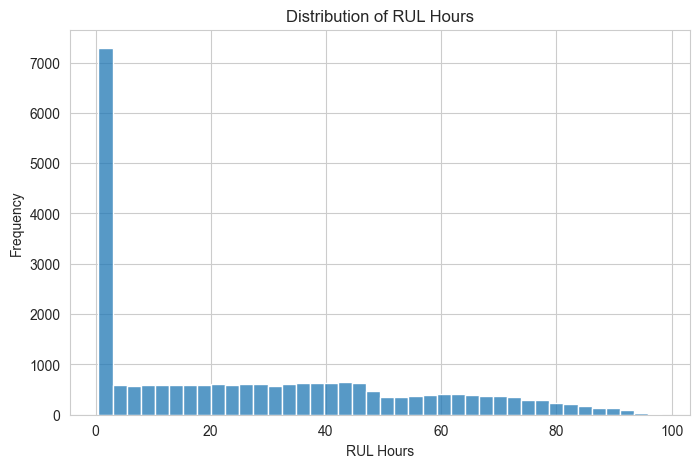

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(data["rul_hours"], bins=40)
plt.title("Distribution of RUL Hours")
plt.xlabel("RUL Hours")
plt.ylabel("Frequency")
plt.show()

### Observation
The target variable is right-skewed, with many machines having lower RUL values and fewer observations at the higher end.  
This suggests the prediction task is challenging, especially for machines with large remaining life.

### 4.2 Machine Type vs RUL

In [12]:
data.groupby("machine_type")["rul_hours"].describe()

,count,mean,std,min,25%,50%,75%,max
machine_type,,,,,,,,
CNC,5937.0,27.417650,26.993932,0.5,0.5000,21.13,47.120,98.34
Compressor,5988.0,31.174574,25.768966,0.5,6.8875,28.15,48.870,96.39
Pump,6114.0,26.545994,25.590306,0.5,0.5000,21.57,44.525,95.66
Robotic Arm,6003.0,26.139300,26.916191,0.5,0.5000,18.30,45.250,94.06


C:\Users\prana\AppData\Local\Temp\ipykernel_9448\2988830359.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="machine_type", y="rul_hours", data=data, palette="Set2")


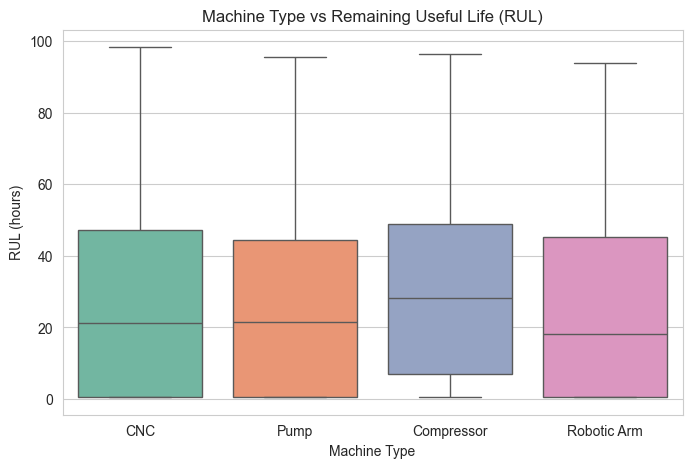

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="machine_type", y="rul_hours", data=data, palette="Set2")
plt.title("Machine Type vs Remaining Useful Life (RUL)")
plt.xlabel("Machine Type")
plt.ylabel("RUL (hours)")
plt.show()

### Observation
RUL varies across machine types. Compressors generally show higher median RUL, while robotic arms tend to have lower values.  
However, the distributions overlap considerably, which suggests that machine type alone is not enough to explain remaining useful life.

### 4.3 Vibration RMS vs RUL

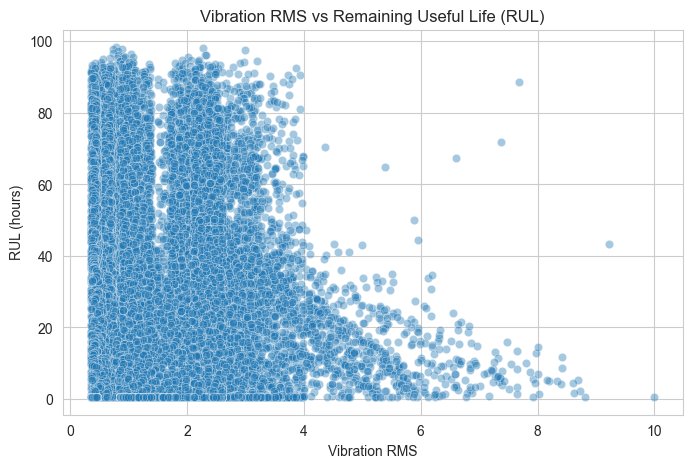

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="vibration_rms", y="rul_hours", data=data, alpha=0.4)
plt.title("Vibration RMS vs Remaining Useful Life (RUL)")
plt.xlabel("Vibration RMS")
plt.ylabel("RUL (hours)")
plt.show()

### Observation
Higher vibration levels are generally associated with lower RUL.  
At the same time, low vibration does not always guarantee high RUL, which means vibration is useful but not sufficient on its own.

### 4.4 Hours Since Maintenance vs RUL

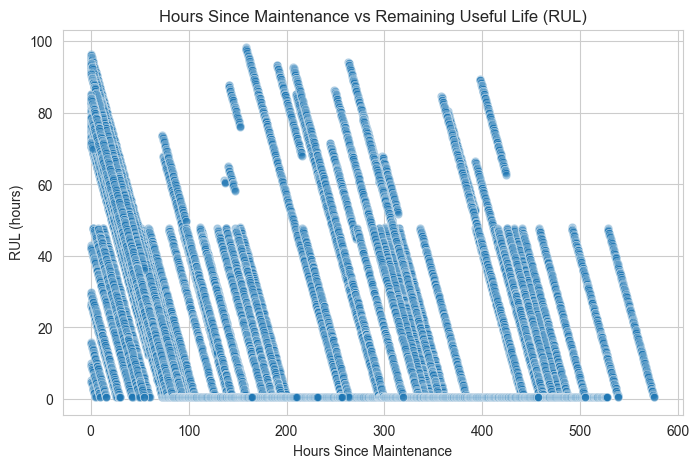

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="hours_since_maintenance", y="rul_hours", data=data, alpha=0.4)
plt.title("Hours Since Maintenance vs Remaining Useful Life (RUL)")
plt.xlabel("Hours Since Maintenance")
plt.ylabel("RUL (hours)")
plt.show()

### Observation
As the hours since maintenance increase, the RUL generally decreases, reflecting the expected wear of machines over time.  
The pattern is not perfectly linear, which indicates that maintenance history should be combined with other sensor features for prediction.

### 4.5 Motor Temperature vs RUL

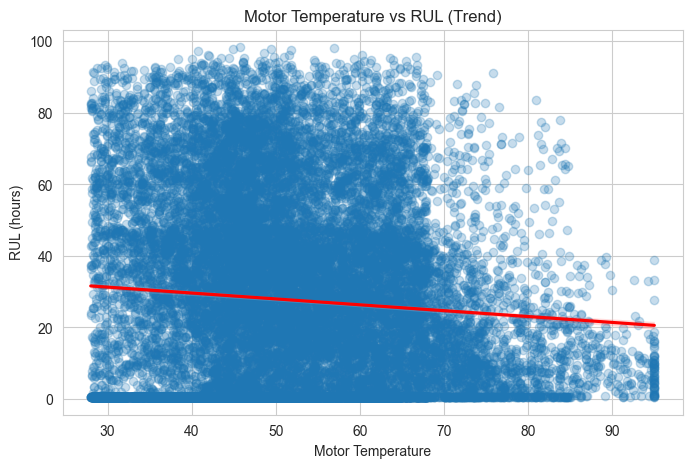

In [16]:
plt.figure(figsize=(8, 5))
sns.regplot(
    x="temperature_motor",
    y="rul_hours",
    data=data,
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"}
)
plt.title("Motor Temperature vs RUL (Trend)")
plt.xlabel("Motor Temperature")
plt.ylabel("RUL (hours)")
plt.show()

### Observation
Motor temperature shows a negative relationship with RUL, meaning higher temperatures are generally linked to faster degradation.  
Still, the spread in the plot suggests temperature should be interpreted together with other machine health indicators.

## 5. Data Cleaning and Preprocessing

### 5.1 Handle Missing Values

In [17]:
# Numerical sensor columns with missing values
sensor_cols = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm"
]

# Group-wise imputation based on machine type
for col in sensor_cols:
    data[col] = data.groupby("machine_type")[col].transform(lambda x: x.fillna(x.median()))
    data[col] = data[col].fillna(data[col].median())  # fallback if any NaNs remain

# Check remaining missing values
data[sensor_cols].isnull().sum()

vibration_rms        0
temperature_motor    0
current_phase_avg    0
pressure_level       0
rpm                  0
dtype: int64

### Observation
Missing values were filled using **group-wise median imputation by machine type**.  
This approach keeps machine-specific patterns more effectively than using a single global value for all machines.

### 5.2 Remove Leakage and Identifier Columns

In [18]:
# Drop columns that should not be used for RUL prediction
data = data.drop(columns=[
    "failure_within_24h",
    "failure_type",
    "estimated_repair_cost"
])

# Drop identifier columns after EDA
data = data.drop(columns=["timestamp", "machine_id"])

data.head()

,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours
0,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00
1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95
2,CNC,0.71,49.70,10.22,21.3,862.7,idle,274.15,13.6,60.65
3,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25
4,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10


### Observation
Failure-related fields and repair cost were removed because they contain future information and would cause data leakage.  
Timestamp and machine ID were also excluded from modelling because they are identifiers rather than predictive features in this tabular setup.

### 5.3 Outlier Handling

In [19]:
# Numerical columns for outlier handling
num_cols = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm",
    "hours_since_maintenance",
    "ambient_temp"
]

def cap_outliers_iqr(df, cols):
    df = df.copy()
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        df[col] = df[col].clip(lower, upper)
    return df

data = cap_outliers_iqr(data, num_cols)
data.head()

,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours
0,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00
1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95
2,CNC,0.71,49.70,10.22,21.3,862.7,idle,274.15,13.6,60.65
3,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25
4,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10


### Observation
Outliers were capped using the IQR method instead of removing rows.  
This reduces the influence of extreme values while preserving the overall size of the dataset.

### 5.4 Skewness Check

In [20]:
data[num_cols].skew().sort_values(ascending=False)

rpm                        1.000304
vibration_rms              0.779615
current_phase_avg          0.750039
hours_since_maintenance    0.734384
pressure_level             0.651506
temperature_motor          0.417121
ambient_temp               0.000119
dtype: float64

### Observation
Most numerical features show only mild to moderate skewness.  
Since tree-based models are robust to such distributions, no additional transformations were applied.

## 6. Feature and Target Split

In [21]:
X = data.drop("rul_hours", axis=1)
y = data["rul_hours"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (24042, 9)
Target shape: (24042,)


## 7. Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (19233, 9)
X_test : (4809, 9)
y_train: (19233,)
y_test : (4809,)


### Observation
The data was split into training and testing sets using an 80:20 ratio.  
This allows the models to be trained on one portion of the dataset and evaluated on unseen data.

## 8. Encoding and Scaling

In [23]:
# Separate categorical and numerical columns
categorical_cols = ["machine_type", "operating_mode"]
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['machine_type', 'operating_mode']
Numerical columns: ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp']


In [24]:
# One-hot encode categorical variables
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align train and test columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded, join="left", axis=1, fill_value=0
)

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape :", X_test_encoded.shape)

Encoded train shape: (19233, 12)
Encoded test shape : (4809, 12)


In [25]:
from sklearn.preprocessing import StandardScaler

# Scale only the numerical columns for models that need scaling
scaler = StandardScaler()

X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_encoded[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_encoded[numerical_cols])

X_train_scaled.head()

,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,machine_type_Compressor,machine_type_Pump,machine_type_Robotic Arm,operating_mode_normal,operating_mode_peak
10484,0.702419,1.381823,0.633764,1.485894,0.054322,1.765373,0.592295,False,True,False,True,False
18424,-0.365497,-0.917741,-0.592102,-0.327052,-0.888168,1.943133,0.522909,False,False,True,True,False
10397,-0.966848,-0.769859,-0.994398,-1.090261,-0.690898,1.602847,-0.795428,False,True,False,False,False
15647,-0.531387,-0.165186,-0.548456,-0.363520,-0.465206,0.593562,0.869840,True,False,False,False,False
6730,0.318799,-0.231733,0.569245,1.433798,0.174833,-0.308946,0.106592,False,True,False,True,False


### Observation
Categorical variables were converted using one-hot encoding, while numerical features were scaled only for models sensitive to feature magnitude.  
Tree-based models were trained on the encoded but unscaled data.

## 9. Model Training and Evaluation

In [26]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

In [27]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2 = r2_score(true, predicted)
    return mae, rmse, r2

In [28]:
def train_scaled_models(X_train, X_test, y_train, y_test):
    models = {
        "Linear Regression": LinearRegression(),
        "Lasso": Lasso(),
        "Ridge": Ridge(),
        "KNN": KNeighborsRegressor()
    }

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae, rmse, r2 = evaluate_model(y_test, y_pred)
        cv_r2 = cross_val_score(model, X_train, y_train, cv=5, scoring="r2").mean()

        results.append({
            "Model": name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "CV_R2": cv_r2
        })

    return pd.DataFrame(results)

In [29]:
def train_tree_models(X_train, X_test, y_train, y_test):
    models = {
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(random_state=42),
        "XGBoost": XGBRegressor(random_state=42),
        "CatBoost": CatBoostRegressor(verbose=False, random_state=42),
        "AdaBoost": AdaBoostRegressor(random_state=42),
        "LGBM Regressor": LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31,
            random_state=42
        )
    }

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae, rmse, r2 = evaluate_model(y_test, y_pred)
        cv_r2 = cross_val_score(model, X_train, y_train, cv=5, scoring="r2").mean()

        results.append({
            "Model": name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "CV_R2": cv_r2
        })

    return pd.DataFrame(results)

In [30]:
# Train models
scaled_results = train_scaled_models(X_train_scaled, X_test_scaled, y_train, y_test)
tree_results = train_tree_models(X_train_encoded, X_test_encoded, y_train, y_test)

# Combine and sort results
final_results = pd.concat([scaled_results, tree_results], ignore_index=True)
final_results = final_results.sort_values(by="R2", ascending=False)

final_results

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000234 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1642
[LightGBM] [Info] Number of data points in the train set: 19233, number of used features: 12
[LightGBM] [Info] Start training from score 27.798016
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000501 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1642
[LightGBM] [Info] Number of data points in the train set: 15386, number of used features: 12
[LightGBM] [Info] Start training from score 27.736763
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM]

,Model,MAE,RMSE,R2,CV_R2
5,Random Forest,9.475602,15.068742,0.671598,0.673534
7,CatBoost,10.646779,15.311442,0.660934,0.656428
9,LGBM Regressor,10.838583,15.436819,0.655358,0.652001
6,XGBoost,10.696543,15.716306,0.642766,0.637935
3,KNN,13.218387,18.533201,0.503233,0.463297
4,Decision Tree,11.005627,21.212540,0.349215,0.375631
8,AdaBoost,18.204378,21.762712,0.315019,0.321057
0,Linear Regression,20.490818,24.392818,0.139450,0.134309
2,Ridge,20.491111,24.393043,0.139434,0.134311
1,Lasso,21.047586,24.864486,0.105848,0.105281


### Observation
Tree-based ensemble models perform much better than linear and distance-based models.  
Random Forest achieved the best overall performance, which indicates that the relationship between the features and RUL is largely non-linear.

## 10. Feature Importance of the Best Model

In [31]:
# Train the best baseline model again for feature importance
best_rf = RandomForestRegressor(random_state=42)
best_rf.fit(X_train_encoded, y_train)

feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
5,hours_since_maintenance,0.555644
4,rpm,0.102467
1,temperature_motor,0.076173
2,current_phase_avg,0.062478
0,vibration_rms,0.061080
3,pressure_level,0.044292
6,ambient_temp,0.036969
7,machine_type_Compressor,0.036475
9,machine_type_Robotic Arm,0.009332
8,machine_type_Pump,0.008838


C:\Users\prana\AppData\Local\Temp\ipykernel_9448\634404245.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


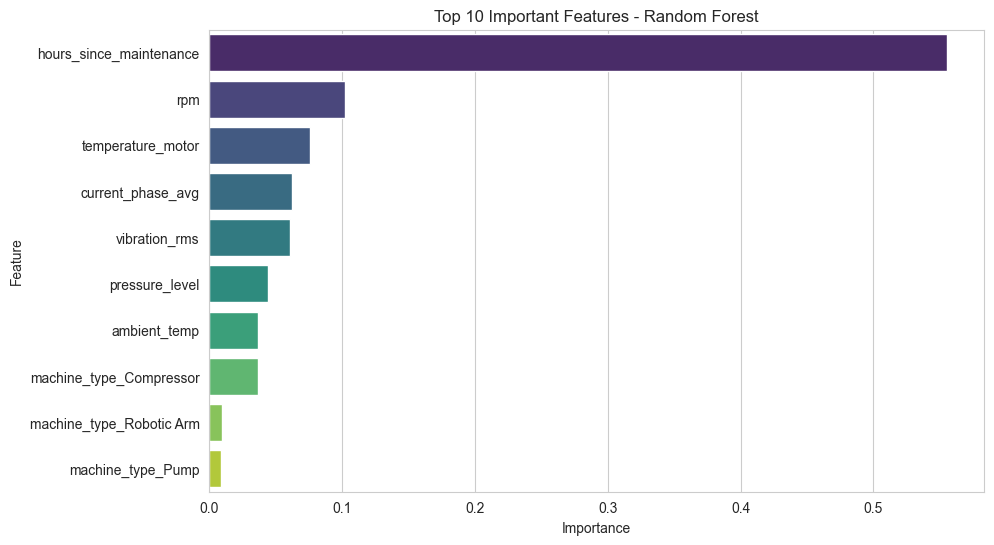

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Observation
The feature importance plot highlights which sensor and operational variables contribute most to RUL prediction.  
This helps explain the model behaviour and provides useful insight into machine degradation patterns.

## 11. Advanced Experiment: Optuna Hyperparameter Tuning for Random Forest

In [33]:
import optuna
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "max_depth": trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)

    scores = cross_val_score(
        model,
        X_train_encoded,
        y_train,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    return scores.mean()

study_rf = optuna.create_study(
    direction="maximize",
    study_name="random_forest_rul_optimization"
)

study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=True)

print("Best Random Forest Parameters:")
print(study_rf.best_params)
print(f"Best Random Forest CV R2: {study_rf.best_value:.4f}")

d:\ML Assignment\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-08 12:30:05,120] A new study created in memory with name: random_forest_rul_optimization
Best trial: 0. Best value: 0.672852:   2%|▏         | 1/50 [00:42<34:34, 42.34s/it]

[I 2026-04-08 12:30:47,460] Trial 0 finished with value: 0.6728521146030702 and parameters: {'n_estimators': 706, 'max_depth': 24, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 0.6728521146030702.


Best trial: 0. Best value: 0.672852:   4%|▍         | 2/50 [01:08<26:27, 33.08s/it]

[I 2026-04-08 12:31:14,062] Trial 1 finished with value: 0.6022997957062731 and parameters: {'n_estimators': 1122, 'max_depth': 15, 'min_samples_split': 19, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.6728521146030702.


Best trial: 0. Best value: 0.672852:   6%|▌         | 3/50 [01:20<18:10, 23.21s/it]

...

[I 2026-04-08 12:55:00,152] Trial 47 finished with value: 0.5676997802211963 and parameters: {'n_estimators': 822, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': False}. Best is trial 23 with value: 0.6737386379905469.


Best trial: 23. Best value: 0.673739:  98%|█████████▊| 49/50 [25:03<00:32, 32.62s/it]

[I 2026-04-08 12:55:08,519] Trial 48 finished with value: 0.5905655658725429 and parameters: {'n_estimators': 548, 'max_depth': 14, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 23 with value: 0.6737386379905469.


Best trial: 23. Best value: 0.673739: 100%|██████████| 50/50 [25:38<00:00, 30.76s/it]

[I 2026-04-08 12:55:43,303] Trial 49 finished with value: 0.6722129020904293 and parameters: {'n_estimators': 591, 'max_depth': 23, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True}. Best is trial 23 with value: 0.6737386379905469.
Best Random Forest Parameters:
{'n_estimators': 813, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True}
Best Random Forest CV R2: 0.6737


In [34]:
best_rf_params = study_rf.best_params.copy()

best_rf = RandomForestRegressor(
    **best_rf_params,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_encoded, y_train)

y_pred_rf_tuned = best_rf.predict(X_test_encoded)

mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print("\nTuned Random Forest Performance on Test Set")
print(f"MAE:  {mae_rf_tuned:.4f}")
print(f"RMSE: {rmse_rf_tuned:.4f}")
print(f"R2:   {r2_rf_tuned:.4f}")


Tuned Random Forest Performance on Test Set
MAE:  9.5294
RMSE: 14.9587
R2:   0.6764


### Observation
Hyperparameter tuning was attempted using Optuna.  
If the tuned model does not outperform the default Random Forest, the baseline configuration can still be selected as the final model because it is simpler and already performs strongly.

## CatBoost Optuna tuning

In [ ]:
import optuna
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def objective_catboost(trial):
    params = {
        "loss_function": "RMSE",
        "eval_metric": "R2",
        "random_state": 42,
        "verbose": 0,

        # Core boosting params
        "iterations": trial.suggest_int("iterations", 300, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "depth": trial.suggest_int("depth", 4, 10),

        # Regularization / robustness
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 15.0),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),

        # Feature / sample control
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0),

        # Tree growth
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
    }

    model = CatBoostRegressor(**params)

    scores = cross_val_score(
        model,
        X_train_encoded,
        y_train,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    return scores.mean()

study_cat = optuna.create_study(
    direction="maximize",
    study_name="catboost_rul_optimization"
)

study_cat.optimize(objective_catboost, n_trials=50, show_progress_bar=True)

print("Best CatBoost Parameters:")
print(study_cat.best_params)
print(f"Best CatBoost CV R2: {study_cat.best_value:.4f}")

[I 2026-04-03 10:56:21,296] A new study created in memory with name: catboost_rul_optimization


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[I 2026-04-03 10:59:26,316] Trial 0 finished with value: 0.6581378619397966 and parameters: {'iterations': 1337, 'learning_rate': 0.11478922043368515, 'depth': 10, 'l2_leaf_reg': 11.276775007958877, 'random_strength': 2.897127059959938, 'bagging_temperature': 1.4139278364744967, 'subsample': 0.9057398324466238, 'colsample_bylevel': 0.7478522484476338, 'min_data_in_leaf': 26}. Best is trial 0 with value: 0.6581378619397966.
[I 2026-04-03 10:59:54,680] Trial 1 finished with value: 0.6380692504637573 and parameters: {'iterations': 895, 'learning_rate': 0.03254686534819501, 'depth': 6, 'l2_leaf_reg': 11.565544866913884, 'random_strength': 0.08855467798043577, 'bagging_temperature': 2.711793419335942, 'subsample': 0.8798688144083548, 'colsample_bylevel': 0.9461591524383852, 'min_data_in_leaf': 50}. Best is trial 0 with value: 0.6581378619397966.
[I 2026-04-03 11:03:23,644] Trial 2 finished with value: 0.6608621667465097 and parameters: {'iterations': 1480, 'learning_rate': 0.070665383184820

In [35]:
import pickle

pickle.dump(best_rf, open("best_rf.pkl", "wb"))

In [36]:
pickle.dump(X_train_encoded.columns.tolist(), open("model_columns.pkl", "wb"))

In [37]:
category_values = {
    "machine_type": sorted(data["machine_type"].dropna().unique().tolist()),
    "operating_mode": sorted(data["operating_mode"].dropna().unique().tolist())
}

pickle.dump(category_values, open("category_values.pkl", "wb"))

In [38]:
num_cols = ['vibration_rms', 'temperature_motor', 'current_phase_avg',
            'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp']

cap_limits = {}

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    cap_limits[col] = {"lower": lower, "upper": upper}

pickle.dump(cap_limits, open("cap_limits.pkl", "wb"))

In [39]:
import pickle

numeric_cols = [
    'vibration_rms',
    'temperature_motor',
    'current_phase_avg',
    'pressure_level',
    'rpm',
    'hours_since_maintenance',
    'ambient_temp'
]

input_ranges = {}

for col in numeric_cols:
    input_ranges[col] = {
        "min": float(data[col].min()),
        "max": float(data[col].max()),
        "q1": float(data[col].quantile(0.25)),
        "q3": float(data[col].quantile(0.75)),
        "median": float(data[col].median())
    }

pickle.dump(input_ranges, open("input_ranges.pkl", "wb"))

In [ ]:
best_cat_params = study_cat.best_params.copy()

best_cat = CatBoostRegressor(
    **best_cat_params,
    loss_function="RMSE",
    eval_metric="R2",
    random_state=42,
    verbose=0
)

best_cat.fit(X_train_encoded, y_train)

y_pred_cat_tuned = best_cat.predict(X_test_encoded)

mae_cat_tuned = mean_absolute_error(y_test, y_pred_cat_tuned)
rmse_cat_tuned = np.sqrt(mean_squared_error(y_test, y_pred_cat_tuned))
r2_cat_tuned = r2_score(y_test, y_pred_cat_tuned)

print("\nTuned CatBoost Performance on Test Set")
print(f"MAE:  {mae_cat_tuned:.4f}")
print(f"RMSE: {rmse_cat_tuned:.4f}")
print(f"R2:   {r2_cat_tuned:.4f}")


Tuned CatBoost Performance on Test Set
MAE:  10.3577
RMSE: 15.1515
R2:   0.6680


## LightGBM Optuna tuning

In [ ]:
from lightgbm import LGBMRegressor

def objective_lgbm(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,

        # Core boosting params
        "n_estimators": trial.suggest_int("n_estimators", 300, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),

        # Data control
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 80),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        # Regularization
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 20.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 20.0, log=True),

        # Split / leaf constraints
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
    }

    model = LGBMRegressor(**params)

    scores = cross_val_score(
        model,
        X_train_encoded,
        y_train,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    return scores.mean()

study_lgbm = optuna.create_study(
    direction="maximize",
    study_name="lgbm_rul_optimization"
)

study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

print("Best LightGBM Parameters:")
print(study_lgbm.best_params)
print(f"Best LightGBM CV R2: {study_lgbm.best_value:.4f}")

[I 2026-04-03 12:15:48,186] A new study created in memory with name: lgbm_rul_optimization


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-03 12:16:51,013] Trial 0 finished with value: 0.6560831493073225 and parameters: {'n_estimators': 1252, 'learning_rate': 0.013792307540898616, 'max_depth': 10, 'num_leaves': 150, 'min_child_samples': 65, 'subsample': 0.9547587830165581, 'colsample_bytree': 0.7445429405457595, 'reg_alpha': 0.000554162949446712, 'reg_lambda': 0.2582707532865394, 'min_split_gain': 0.25851516196498125, 'min_child_weight': 0.0402098942087451}. Best is trial 0 with value: 0.6560831493073225.
[I 2026-04-03 12:17:36,512] Trial 1 finished with value: 0.6433643288538884 and parameters: {'n_estimators': 839, 'learning_rate': 0.06449317490859635, 'max_depth': 12, 'num_leaves': 169, 'min_child_samples': 31, 'subsample': 0.71651210341884, 'colsample_bytree': 0.6984083652576939, 'reg_alpha': 0.000368815083737939, 'reg_lambda': 0.0025940033104998785, 'min_split_gain': 0.8977490208525775, 'min_child_weight': 0.05658082837340244}. Best is trial 0 with value: 0.6560831493073225.


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[I 2026-04-03 12:18:28,839] Trial 2 finished with value: 0.6370403463499101 and parameters: {'n_estimators': 1299, 'learning_rate': 0.009578349791435537, 'max_depth': 8, 'num_leaves': 196, 'min_child_samples': 78, 'subsample': 0.7060171301015186, 'colsample_bytree': 0.702433533049387, 'reg_alpha': 1.8632508331016326, 'reg_lambda': 15.892777270865494, 'min_split_gain': 0.2702427501112905, 'min_child_weight': 0.223291810114295}. Best is trial 0 with value: 0.6560831493073225.
[I 2026-04-03 12:18:58,363] Trial 3 finished with value: 0.6496698420588081 and parameters: {'n_estimators': 804, 'learning_rate': 0.0623863298413413, 'max_depth': 9, 'num_leaves': 32, 'min_child_samples': 73, 'subsample': 0.9253898897653529, 'colsample_bytree': 0.8992736003426685, 'reg_alpha': 5.5255606262602255, 'reg_lambda': 0.00446681649533993, 'min_split_gain': 0.7408110692668235, 'min_child_weight': 0.02507749155759064}. Best is trial 0 with value: 0.6560831493073225.
[I 2026-04-03 12:19:45,625] Trial 4 finish

In [ ]:
best_lgbm_params = study_lgbm.best_params.copy()

best_lgbm = LGBMRegressor(
    **best_lgbm_params,
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

best_lgbm.fit(X_train_encoded, y_train)

y_pred_lgbm_tuned = best_lgbm.predict(X_test_encoded)

mae_lgbm_tuned = mean_absolute_error(y_test, y_pred_lgbm_tuned)
rmse_lgbm_tuned = np.sqrt(mean_squared_error(y_test, y_pred_lgbm_tuned))
r2_lgbm_tuned = r2_score(y_test, y_pred_lgbm_tuned)

print("\nTuned LightGBM Performance on Test Set")
print(f"MAE:  {mae_lgbm_tuned:.4f}")
print(f"RMSE: {rmse_lgbm_tuned:.4f}")
print(f"R2:   {r2_lgbm_tuned:.4f}")


Tuned LightGBM Performance on Test Set
MAE:  10.1137
RMSE: 15.1479
R2:   0.6681


[I 2026-04-03 14:10:00,585] A new study created in memory with name: random_forest_rul_optimization


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-03 14:12:03,013] Trial 0 finished with value: 0.6248790837119353 and parameters: {'n_estimators': 542, 'max_depth': 30, 'min_samples_split': 13, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.6248790837119353.
[I 2026-04-03 14:19:48,063] Trial 1 finished with value: 0.5840324512987347 and parameters: {'n_estimators': 979, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 0.6248790837119353.
[I 2026-04-03 14:22:47,589] Trial 2 finished with value: 0.6218547506479868 and parameters: {'n_estimators': 881, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.6248790837119353.
[I 2026-04-03 14:25:00,452] Trial 3 finished with value: 0.457927636322237 and parameters: {'n_estimators': 501, 'max_depth': 5, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_featu

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[I 2026-04-03 14:37:00,234] Trial 7 finished with value: 0.6403621623739074 and parameters: {'n_estimators': 956, 'max_depth': 22, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 4 with value: 0.6661604248897633.
[I 2026-04-03 14:37:51,243] Trial 8 finished with value: 0.3786145237389119 and parameters: {'n_estimators': 905, 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 4 with value: 0.6661604248897633.
[I 2026-04-03 14:38:48,612] Trial 9 finished with value: 0.5578911421138719 and parameters: {'n_estimators': 371, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False}. Best is trial 4 with value: 0.6661604248897633.
[I 2026-04-03 14:48:27,605] Trial 10 finished with value: 0.6668992647443442 and parameters: {'n_estimators': 1152, 'max_depth': 38, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_fe